# Notebook 04 — Urban Environmental Time Series

**หัวข้อ:** Urban Environmental Time Series

**คำถามหลัก:** *Vegetation และ Land Surface Temperature เปลี่ยนแปลงตามฤดูกาลและระหว่างปีอย่างไร?*

### วัตถุประสงค์การเรียนรู้
- อธิบาย trend, seasonality และ variability
- เข้าใจ spatial averaging และ temporal aggregation
- เปลี่ยน `ImageCollection` ให้เป็นตาราง time series
- เชื่อม Earth Engine กับ Pandas
- สร้าง professional line plot
- ตีความ seasonal relationship ระหว่าง NDVI และ LST
- เข้าใจ spatial–temporal resolution trade-off

## 1. แนวคิด Time Series

แผนที่ 1 ภาพตอบคำถามว่า **“ที่ไหน?”**  
Time series ช่วยตอบว่า **“เมื่อไร และเปลี่ยนอย่างไร?”**

คำศัพท์หลัก:
- **Trend**: แนวโน้มระยะยาว
- **Seasonality**: รูปแบบที่เกิดซ้ำตามฤดูกาล
- **Variability**: ความผันแปร
- **Anomaly**: ค่าที่เบี่ยงเบนจากค่าปกติ/ค่าเฉลี่ยอ้างอิง

Notebook นี้ใช้ MODIS เพราะ temporal continuity เหมาะกับการสอน time series แม้ spatial resolution หยาบกว่า Sentinel-2

## การเตรียมระบบ (ทำทุก Notebook)

Notebook นี้ออกแบบสำหรับ **Google Colab + Google Earth Engine Python API + geemap**

### ก่อนเริ่ม
1. ต้องมีบัญชี Google Earth Engine ที่เปิดใช้งานแล้ว
2. ต้องมี Google Cloud Project ที่ใช้กับ Earth Engine
3. แก้ค่า `PROJECT` ใน code cell ด้านล่างให้เป็น Project ID ของตนเอง

> **แนวคิดสำคัญ:** Python ใน Colab เป็นฝั่งผู้ใช้ (client) ส่วน `ee.Image`, `ee.ImageCollection` และการคำนวณส่วนใหญ่เป็นวัตถุแบบ server-side ที่ประมวลผลบน Google Earth Engine

In [1]:
%pip install -q earthengine-api geemap pandas matplotlib scikit-learn scipy

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Cloud Project ID ที่ลงทะเบียน Earth Engine แล้ว
PROJECT = "project-cf559859-d42a-44d4-925"

try:
    ee.Initialize(project=PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)

print("Earth Engine initialized successfully.")
print("Using project:", PROJECT)

# -------------------------------------------------------------------
# ฟังก์ชันมาตรฐานสำหรับทุกแผนที่ในรายวิชา
# 1) สร้าง geemap.Map()
# 2) ลบ default OpenStreetMap ที่ถูก block ใน Colab environment นี้
# 3) ใช้ Esri.WorldImagery เป็น basemap เริ่มต้น
# 4) เตรียม Street Map และ Topographic Map ไว้ให้เลือกใน Layer Control
# -------------------------------------------------------------------
def create_course_map():
    m = geemap.Map()
    m.clear_layers()
    m.add_basemap("Esri.WorldImagery", show=True)
    m.add_basemap("Esri.WorldStreetMap", show=False)
    m.add_basemap("Esri.WorldTopoMap", show=False)
    return m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.0 MB/s eta 0:00:00
Earth Engine initialized successfully.
Using project: project-cf559859-d42a-44d4-925


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


### Basemap ที่ใช้ในชุด Notebook นี้

ทุกแผนที่เรียกผ่าน `create_course_map()` เพื่อหลีกเลี่ยง default OpenStreetMap tile ที่ถูก block ใน Colab environment นี้ โดยกำหนด **Esri.WorldImagery** เป็นพื้นหลังเริ่มต้น และมี **Esri.WorldStreetMap** กับ **Esri.WorldTopoMap** ให้เปิดจาก Layer Control ตามวัตถุประสงค์ของการอ่านแผนที่


## 2. กำหนด Urban Analysis Zone แบบเดียวกับ Notebook 03

ใช้รัศมี 20 km รอบศูนย์กลางเมืองเพื่อทำให้ definition ของพื้นที่วิเคราะห์ชัดเจนและทำซ้ำได้

In [2]:
BKK_CENTER = ee.Geometry.Point([100.5018, 13.7563])
CM_CENTER  = ee.Geometry.Point([98.9853, 18.7883])

bkk_zone = BKK_CENTER.buffer(20_000)
cm_zone  = CM_CENTER.buffer(20_000)

START = "2019-01-01"
END   = "2025-01-01"

## 3. MODIS Monthly NDVI

Dataset: `MODIS/061/MOD13A3`

- Temporal resolution: monthly
- Spatial resolution: 1 km
- NDVI scale factor: 0.0001
- ใช้ `SummaryQA <= 1` เพื่อเก็บ good + marginal quality

In [3]:
def prep_modis_ndvi(image):
    good = image.select("SummaryQA").lte(1)
    return (
        image.select("NDVI")
        .multiply(0.0001)
        .rename("NDVI")
        .updateMask(good)
        .copyProperties(image, ["system:time_start"])
    )

ndvi_ic = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterDate(START, END)
    .map(prep_modis_ndvi)
)

print("Monthly NDVI images:", ndvi_ic.size().getInfo())

Monthly NDVI images: 72


## 4. MODIS 8-day LST

Dataset: `MODIS/061/MOD11A2`

- Spatial resolution: 1 km
- Temporal resolution: 8-day
- `LST_Day_1km` scale factor = 0.02 K
- ใช้ `QC_Day` bits 0–1 = 0 สำหรับ good quality

เราจะ extract 8-day values ก่อน แล้ว aggregate เป็น monthly mean ใน Pandas

In [4]:
def prep_modis_lst(image):
    qc = image.select("QC_Day")
    good = qc.bitwiseAnd(3).eq(0)

    return (
        image.select("LST_Day_1km")
        .multiply(0.02)
        .subtract(273.15)
        .rename("LST_C")
        .updateMask(good)
        .copyProperties(image, ["system:time_start"])
    )

lst_ic = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(START, END)
    .map(prep_modis_lst)
)

print("8-day LST images:", lst_ic.size().getInfo())

8-day LST images: 276


## 5. Function: ImageCollection → Regional Time Series

เราใช้ `reduceRegion(mean)` กับแต่ละ image เพื่อเปลี่ยน raster time series เป็นชุดข้อมูล `date + value`

จำนวน record ในตัวอย่างนี้มีเพียงหลักร้อย จึงสามารถนำผลสรุปที่ลดรูปแล้วกลับมายัง Pandas ได้อย่างเหมาะสม

In [5]:
def region_series_to_df(image_collection, band, region, scale):
    n = image_collection.size().getInfo()
    image_list = image_collection.toList(n)
    indices = ee.List.sequence(0, n - 1)

    def image_to_feature(i):
        img = ee.Image(image_list.get(i))
        value = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e8,
            bestEffort=True,
        ).get(band)

        return ee.Feature(
            None,
            {
                "date": img.date().format("YYYY-MM-dd"),
                "value": value,
            }
        )

    fc = ee.FeatureCollection(indices.map(image_to_feature))
    fc = fc.filter(ee.Filter.notNull(["value"]))

    info = fc.getInfo()["features"]
    rows = [f["properties"] for f in info]
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"])
    return df.sort_values("date").reset_index(drop=True)

## 6. สาธิต — Bangkok

In [6]:
bkk_ndvi = region_series_to_df(ndvi_ic, "NDVI", bkk_zone, 1000)
bkk_lst8 = region_series_to_df(lst_ic, "LST_C", bkk_zone, 1000)

bkk_ndvi["month"] = bkk_ndvi["date"].dt.to_period("M").dt.to_timestamp()
bkk_ndvi_m = bkk_ndvi.groupby("month", as_index=False)["value"].mean()
bkk_ndvi_m = bkk_ndvi_m.rename(columns={"value": "NDVI"})

bkk_lst8["month"] = bkk_lst8["date"].dt.to_period("M").dt.to_timestamp()
bkk_lst_m = bkk_lst8.groupby("month", as_index=False)["value"].mean()
bkk_lst_m = bkk_lst_m.rename(columns={"value": "LST_C"})

bkk_ts = pd.merge(bkk_ndvi_m, bkk_lst_m, on="month", how="inner")
bkk_ts.head()

,month,NDVI,LST_C
0,2019-01-01,0.412313,32.082879
1,2019-02-01,0.390205,33.999202
2,2019-03-01,0.383757,36.621798
3,2019-04-01,0.415639,37.633781
4,2019-05-01,0.462419,37.707373


## 7. Professional Time-Series Plots

หลักการ:
- ไม่ใช้ 3D
- แกน y ต้องมีหน่วย
- ใช้ title ที่บอกพื้นที่และ period
- ใช้กราฟแยก NDVI กับ LST แทน dual y-axis ในการเรียนครั้งแรก
- grid เป็นเพียงตัวช่วย ไม่ควรเด่นกว่าข้อมูล

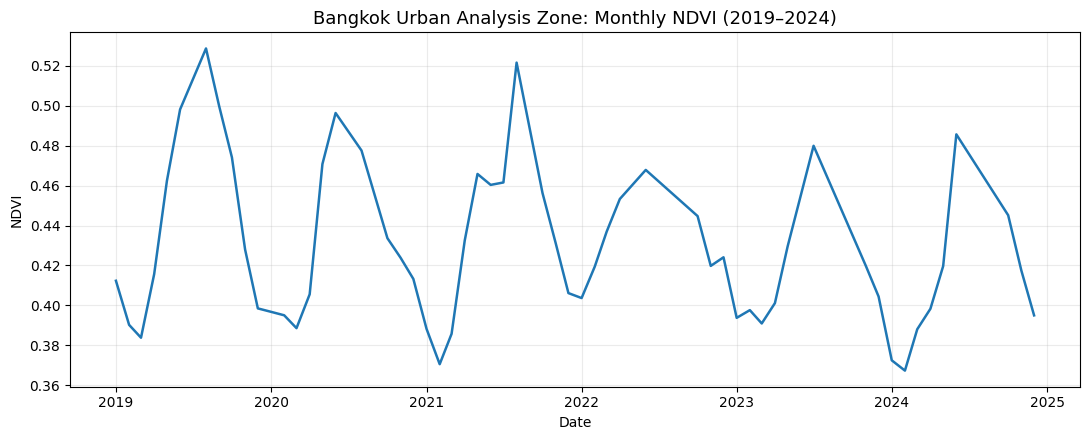

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bkk_ts["month"], bkk_ts["NDVI"], linewidth=1.8)
ax.set_title("Bangkok Urban Analysis Zone: Monthly NDVI (2019–2024)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

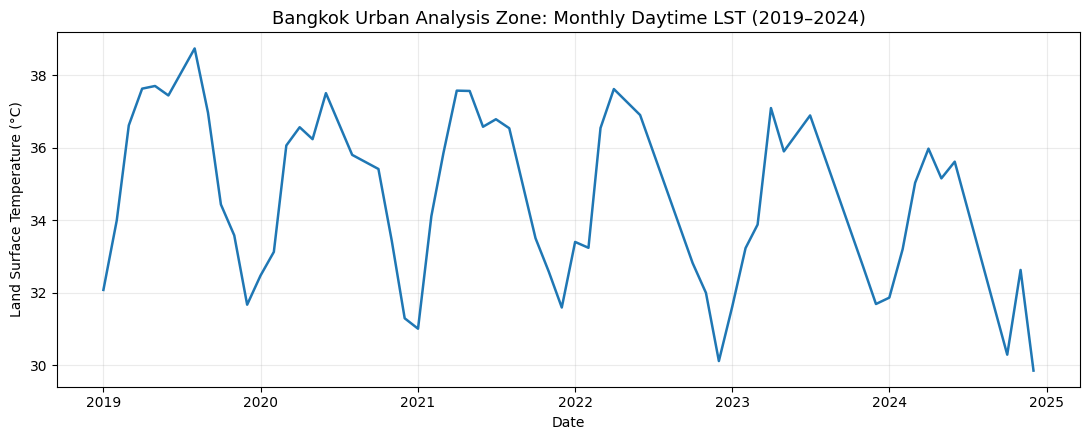

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bkk_ts["month"], bkk_ts["LST_C"], linewidth=1.8)
ax.set_title("Bangkok Urban Analysis Zone: Monthly Daytime LST (2019–2024)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Land Surface Temperature (°C)")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Seasonal Climatology

รวมเดือนเดียวกันจากหลายปี เพื่อเห็น seasonal cycle ที่อ่านง่าย

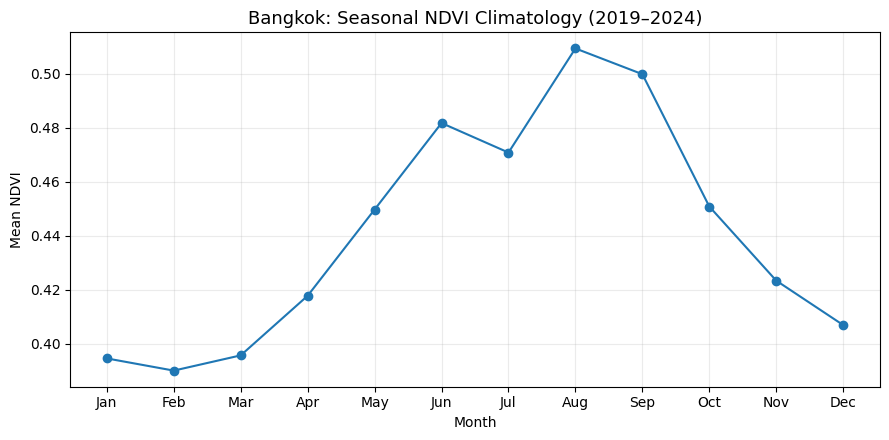

In [9]:
bkk_ts["month_num"] = bkk_ts["month"].dt.month

bkk_clim = (
    bkk_ts.groupby("month_num")[["NDVI", "LST_C"]]
    .mean()
    .reset_index()
)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(bkk_clim["month_num"], bkk_clim["NDVI"], marker="o")
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean NDVI")
ax.set_title("Bangkok: Seasonal NDVI Climatology (2019–2024)", fontsize=13)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

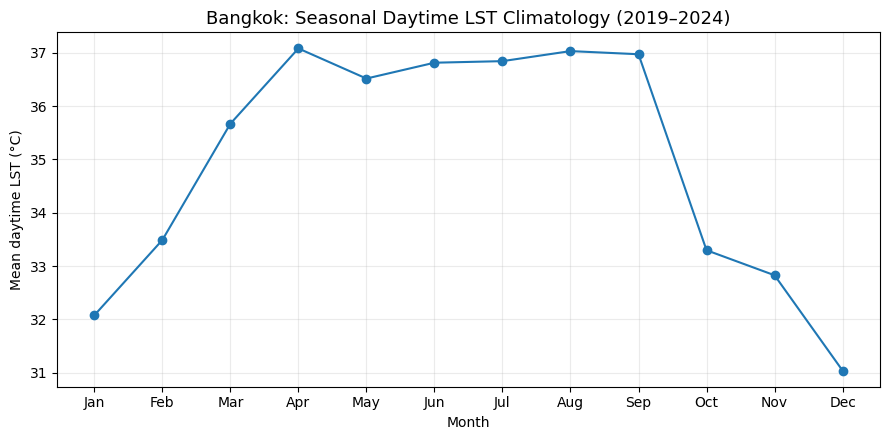

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(bkk_clim["month_num"], bkk_clim["LST_C"], marker="o")
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daytime LST (°C)")
ax.set_title("Bangkok: Seasonal Daytime LST Climatology (2019–2024)", fontsize=13)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 9. แบบฝึกหัด — Chiang Mai

สร้าง:
1. Monthly NDVI 2019–2024
2. Monthly daytime LST 2019–2024
3. Seasonal NDVI climatology 12 เดือน
4. Seasonal LST climatology 12 เดือน

ตอบ:
- เดือนไหนมี mean NDVI สูงสุด/ต่ำสุด?
- เดือนไหนมี mean daytime LST สูงสุด/ต่ำสุด?
- รูปแบบ seasonality สอดคล้องกับฤดูฝน/ฤดูร้อนอย่างไร?
- การใช้ MODIS 1 km มีข้อดีและข้อจำกัดอะไรเมื่อเทียบกับ Sentinel-2 10 m?

In [11]:
# TODO:
# cm_ndvi = region_series_to_df(...)
# cm_lst8 = region_series_to_df(...)
# aggregate เป็น monthly
# merge NDVI + LST
# plot time series และ seasonal climatology

## 10. สิ่งที่ควรได้จาก Notebook 04

- แผนที่หนึ่งภาพเป็นเพียง snapshot
- dataset ที่เหมาะกับ spatial detail อาจไม่ใช่ dataset ที่ดีที่สุดสำหรับ temporal monitoring
- Earth Engine ใช้ลดรูป geospatial data; Pandas ใช้วิเคราะห์ time-series table ต่อ
- seasonality ต้องแยกจาก trend และ anomaly

# SOLUTION — เปิดหลังทำแบบฝึกหัดแล้ว

Highest NDVI month: 9
Lowest NDVI month: 3
Highest LST month: 6
Lowest LST month: 12


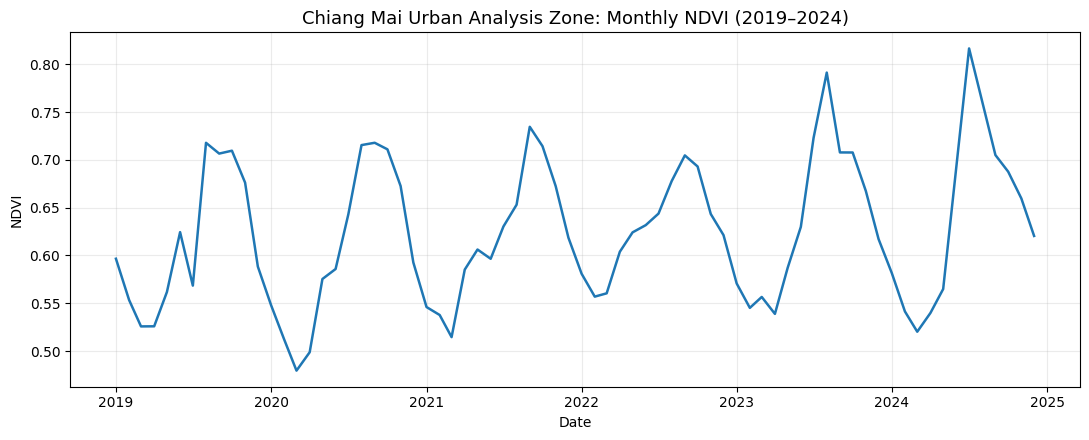

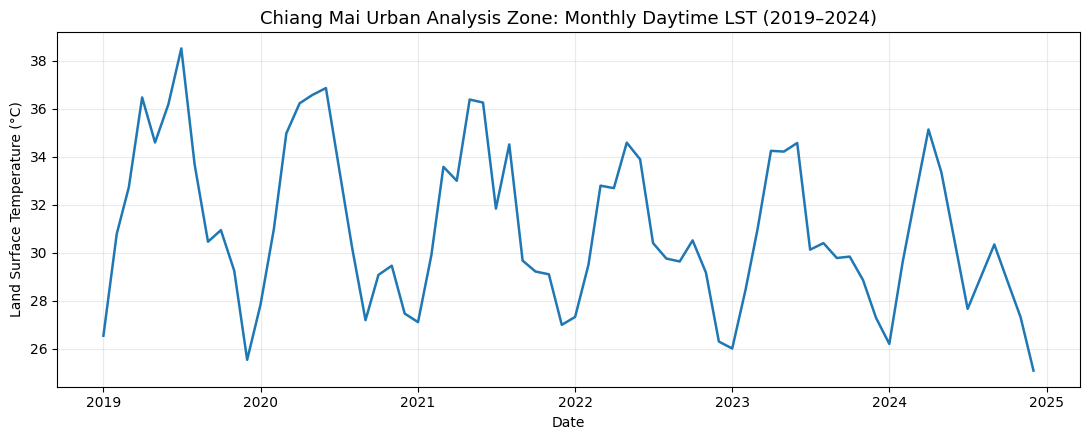

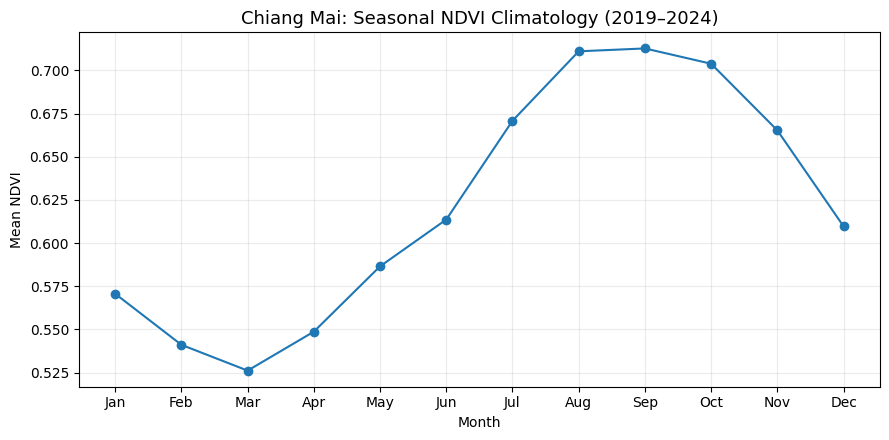

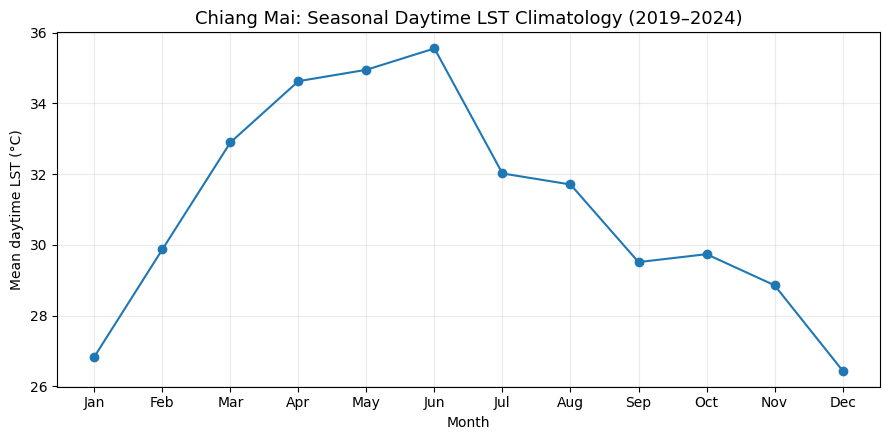

In [12]:
cm_ndvi = region_series_to_df(ndvi_ic, "NDVI", cm_zone, 1000)
cm_lst8 = region_series_to_df(lst_ic, "LST_C", cm_zone, 1000)

cm_ndvi["month"] = cm_ndvi["date"].dt.to_period("M").dt.to_timestamp()
cm_ndvi_m = cm_ndvi.groupby("month", as_index=False)["value"].mean()
cm_ndvi_m = cm_ndvi_m.rename(columns={"value": "NDVI"})

cm_lst8["month"] = cm_lst8["date"].dt.to_period("M").dt.to_timestamp()
cm_lst_m = cm_lst8.groupby("month", as_index=False)["value"].mean()
cm_lst_m = cm_lst_m.rename(columns={"value": "LST_C"})

cm_ts = pd.merge(cm_ndvi_m, cm_lst_m, on="month", how="inner")
cm_ts["month_num"] = cm_ts["month"].dt.month

cm_clim = (
    cm_ts.groupby("month_num")[["NDVI", "LST_C"]]
    .mean()
    .reset_index()
)

print("Highest NDVI month:",
      int(cm_clim.loc[cm_clim["NDVI"].idxmax(), "month_num"]))
print("Lowest NDVI month:",
      int(cm_clim.loc[cm_clim["NDVI"].idxmin(), "month_num"]))
print("Highest LST month:",
      int(cm_clim.loc[cm_clim["LST_C"].idxmax(), "month_num"]))
print("Lowest LST month:",
      int(cm_clim.loc[cm_clim["LST_C"].idxmin(), "month_num"]))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cm_ts["month"], cm_ts["NDVI"], linewidth=1.8)
ax.set_title("Chiang Mai Urban Analysis Zone: Monthly NDVI (2019–2024)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cm_ts["month"], cm_ts["LST_C"], linewidth=1.8)
ax.set_title("Chiang Mai Urban Analysis Zone: Monthly Daytime LST (2019–2024)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Land Surface Temperature (°C)")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cm_clim["month_num"], cm_clim["NDVI"], marker="o")
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean NDVI")
ax.set_title("Chiang Mai: Seasonal NDVI Climatology (2019–2024)", fontsize=13)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cm_clim["month_num"], cm_clim["LST_C"], marker="o")
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daytime LST (°C)")
ax.set_title("Chiang Mai: Seasonal Daytime LST Climatology (2019–2024)", fontsize=13)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## แหล่งข้อมูลอ้างอิง
- MOD13A3.061 Monthly NDVI: https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD13A3
- MOD11A2.061 8-day LST: https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD11A2